In [4]:
from google.colab import files
uploaded = files.upload()

Saving ENB2012_data.xlsx to ENB2012_data (1).xlsx


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ First_Dense (Dense) │ (None, 128)       │      1,152 │ Input_Layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ First_Dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Second_Dense        │ (None, 128)       │     16,512 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ Second_Dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Second_Output__Fir… │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ Second_Output__F… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ First_Output__Last… │ (None, 1)         │        129 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Second_Output__Las… │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,114 (102.01 KB)

 Trainable params: 26,114 (102.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 136: early stopping
Restoring model weights from the end of the best epoch: 126.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
İlk çıkış R2 : 0.8269827254000042
İkinci çıkış R2 : 0.7750602950945503


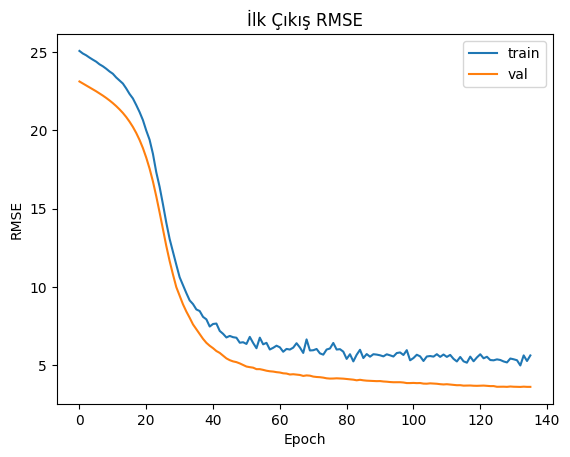

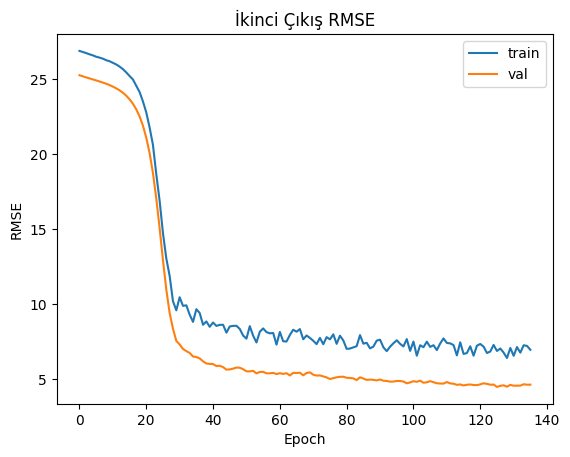

In [3]:
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ======================
# DATA
# ======================
dataset = pd.read_excel('ENB2012_data.xlsx').values
X = dataset[:, 0:8]
y = dataset[:, 8:10]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

sc = StandardScaler()
data_x_train_scaled = sc.fit_transform(X_train)
data_x_test_scaled = sc.transform(X_test)

data_y_train = (y_train[:, 0], y_train[:, 1])

# ======================
# MODEL
# ======================
input_layer = Input(
    shape=(data_x_train_scaled.shape[1],),
    name='Input_Layer'
)

common_path = Dense(128, activation='relu', name='First_Dense')(input_layer)
common_path = Dropout(0.3)(common_path)
common_path = Dense(128, activation='relu', name='Second_Dense')(common_path)
common_path = Dropout(0.3)(common_path)

first_output = Dense(1, name='First_Output__Last_Layer')(common_path)

second_output_path = Dense(64, activation='relu', name='Second_Output__First_Dense')(common_path)
second_output_path = Dropout(0.3)(second_output_path)
second_output = Dense(1, name='Second_Output__Last_Layer')(second_output_path)

model = Model(
    inputs=input_layer,
    outputs=[first_output, second_output]
)

model.summary()

# ======================
# COMPILE
# ======================
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss={
        'First_Output__Last_Layer': 'mse',
        'Second_Output__Last_Layer': 'mse'
    },
    metrics={
        'First_Output__Last_Layer': tf.keras.metrics.RootMeanSquaredError(),
        'Second_Output__Last_Layer': tf.keras.metrics.RootMeanSquaredError()
    }
)

# ======================
# TRAIN
# ======================
earlyStopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    data_x_train_scaled,
    data_y_train,
    epochs=500,
    batch_size=10,
    validation_split=0.3,
    callbacks=[earlyStopping_callback],
    verbose=0
)

# ======================
# TEST
# ======================
y_pred = model.predict(data_x_test_scaled)

print("İlk çıkış R2 :", r2_score(y_test[:, 0], y_pred[0].flatten()))
print("İkinci çıkış R2 :", r2_score(y_test[:, 1], y_pred[1].flatten()))

# ======================
# PLOTS
# ======================
plt.plot(history.history['First_Output__Last_Layer_root_mean_squared_error'])
plt.plot(history.history['val_First_Output__Last_Layer_root_mean_squared_error'])
plt.title('İlk Çıkış RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend(['train', 'val'])
plt.show()

plt.plot(history.history['Second_Output__Last_Layer_root_mean_squared_error'])
plt.plot(history.history['val_Second_Output__Last_Layer_root_mean_squared_error'])
plt.title('İkinci Çıkış RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend(['train', 'val'])
plt.show()
